In [2]:
# === TRANSFORMAÇÃO E ANÁLISE DO DATASET DDoS (versão Jupyter) ===

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Mostrar todas as colunas quando imprimir DataFrames
pd.set_option("display.max_columns", None)

# Tente encontrar o arquivo em caminhos comuns
candidatos = [
    "./datasets/DDoS.csv",
    "../datasets/DDoS.csv",
    "../../datasets/DDoS.csv",
    "DDoS.csv"
]
caminho_ddos = next((p for p in candidatos if os.path.exists(p)), None)
if not caminho_ddos:
    raise FileNotFoundError(
        "Não encontrei DDoS.csv. Coloque em ./datasets/ ou no mesmo diretório do notebook."
    )

print("Arquivo encontrado em:", caminho_ddos)


Arquivo encontrado em: ../datasets/DDoS.csv


In [3]:
# Leitura com fallback de encoding
try:
    df_ddos = pd.read_csv(caminho_ddos, encoding="utf-8")
except UnicodeDecodeError:
    df_ddos = pd.read_csv(caminho_ddos, encoding="latin1")

print("Formato:", df_ddos.shape)
display(df_ddos.head())

# Dica: se houver colunas claramente de identificadores (IPs/portas), podemos removê-las mais abaixo.


Formato: (852585, 9)


,Highest Layer,Transport Layer,Source IP,Dest IP,Source Port,Dest Port,Packet Length,Packets/Time,target
0,ARP,UDP,1,192.168.1.1,0,0,60,92.8,1
1,ARP,UDP,0,192.168.1.10,0,0,42,92.9,0
2,ARP,UDP,1,192.168.1.1,0,0,60,362.8,1
3,ARP,UDP,0,192.168.1.12,0,0,42,362.8,0
4,ARP,UDP,1,192.168.1.1,0,0,60,364.3,1


In [4]:
# Possíveis nomes de coluna-alvo mais comuns
candidatos_alvo = [
    "target", "Target", "label", "Label", "classe", "Classe",
    "attack_type", "Attack_type", "Category", "category"
]

coluna_alvo = next((c for c in candidatos_alvo if c in df_ddos.columns), None)

if coluna_alvo is None:
    # fallback: tenta algo contendo 'class' no nome
    possiveis = [c for c in df_ddos.columns if re.search(r"class|label|target", c, flags=re.I)]
    if possiveis:
        coluna_alvo = possiveis[0]

if coluna_alvo is None:
    raise ValueError(
        "Não consegui identificar a coluna-alvo automaticamente. "
        "Informe o nome correto (ex.: 'target', 'Classe', 'Label'). "
        f"Colunas disponíveis: {list(df_ddos.columns)}"
    )

print("Coluna-alvo detectada:", coluna_alvo)


Coluna-alvo detectada: target


In [5]:
df = df_ddos.copy()

# Remover identificadores muito específicos (ajuste se necessário)
possiveis_identificadores = [
    "source IP","src_ip","dest IP","dst_ip","source port","src_port",
    "Dest Port","dst_port","Flow ID","flow_id","Timestamp","timestamp"
]
para_remover = [c for c in possiveis_identificadores if c in df.columns]
if para_remover:
    df = df.drop(columns=para_remover)

# Se a coluna alvo for categórica (string), converte para rótulos numéricos
y_raw = df[coluna_alvo]
if y_raw.dtype == "object" or str(y_raw.dtype).startswith("category"):
    y_map, uniques = pd.factorize(y_raw)
    y = pd.Series(y_map, name=coluna_alvo)
    print("Mapeamento de classes:", dict(enumerate(uniques.tolist())))
else:
    y = y_raw.astype(int) if np.issubdtype(y_raw.dtype, np.integer) else y_raw

# X = tudo menos a coluna alvo
X = df.drop(columns=[coluna_alvo])

# Converte tudo que não for numérico em dummies
colunas_nao_numericas = X.select_dtypes(include=["object","category"]).columns.tolist()
if colunas_nao_numericas:
    X = pd.get_dummies(X, columns=colunas_nao_numericas, drop_first=True)

# Tenta converter colunas numéricas para tipo adequado
for c in X.columns:
    if not np.issubdtype(X[c].dtype, np.number):
        X[c] = pd.to_numeric(X[c], errors="ignore")

print("Formato final de X:", X.shape)
display(X.head())


Formato final de X: (852585, 30)


C:\Users\Bruno\AppData\Local\Temp\ipykernel_21584\2360960438.py:32: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X[c] = pd.to_numeric(X[c], errors="ignore")


,Source IP,Source Port,Packet Length,Packets/Time,Highest Layer_BOOTP,Highest Layer_BROWSER,Highest Layer_DATA,Highest Layer_DHCPV6,Highest Layer_LLMNR,Highest Layer_NBNS,Highest Layer_QUIC,Highest Layer_SSDP,Highest Layer_TCP,Transport Layer_UDP,Dest IP_169.254.218.126,Dest IP_169.254.255.255,Dest IP_172.16.255.255,Dest IP_172.16.7.100,Dest IP_192.168.1.1,Dest IP_192.168.1.10,Dest IP_192.168.1.11,Dest IP_192.168.1.12,Dest IP_192.168.1.2,Dest IP_192.168.1.255,Dest IP_192.168.1.3,Dest IP_224.0.0.252,Dest IP_239.255.255.250,Dest IP_255.255.255.255,Dest IP_ff02::1:2,Dest IP_ff02::1:3
0,1,0,60,92.8,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,0,0,42,92.9,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,1,0,60,362.8,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,0,0,42,362.8,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,1,0,60,364.3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


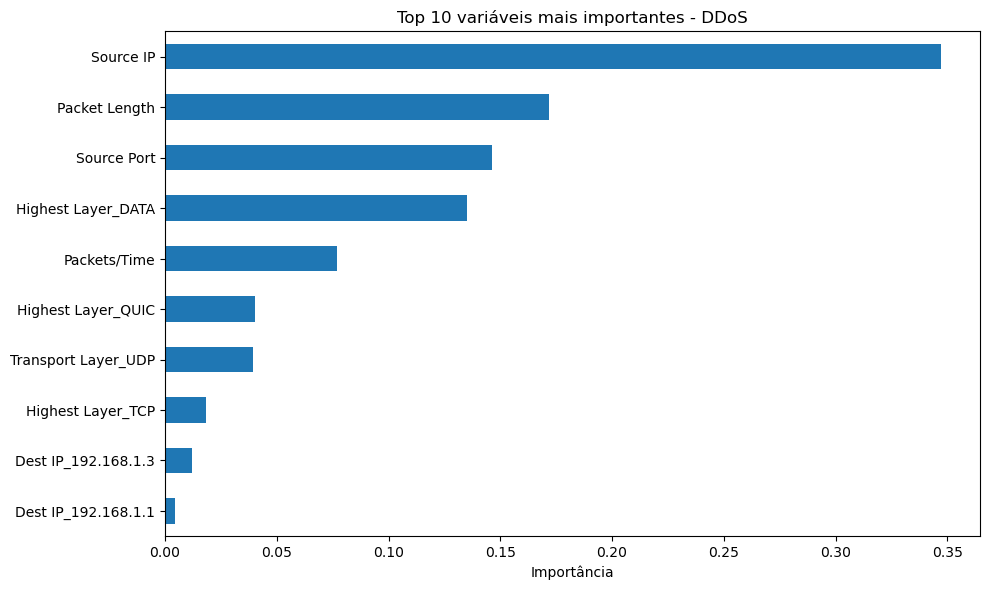

,importance
Source IP,0.347236
Packet Length,0.171597
Source Port,0.146186
Highest Layer_DATA,0.135066
Packets/Time,0.077064
Highest Layer_QUIC,0.040433
Transport Layer_UDP,0.039237
Highest Layer_TCP,0.018157
Dest IP_192.168.1.3,0.012107
Dest IP_192.168.1.1,0.004616


In [6]:
# OBS: para avaliação adequada, o ideal é separar treino/teste ou usar validação cruzada.
# Aqui focamos na importância de features, como no seu código original.

modelo = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo.fit(X, y)

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 10
plt.figure(figsize=(10, 6))
importancias.head(top_n).plot(kind="barh")
plt.title(f"Top {top_n} variáveis mais importantes - DDoS")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(importancias.head(25).to_frame("importance"))
